# Deep Learning Individual Project — Submission

**Student ID:** s3343711

---

## Academic Honesty Declaration

I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.

## Introduction

This project implements a deep learning solution for **multiclass image classification** on a custom dataset containing 16,000 grayscale images (32×32 pixels) distributed across 4 classes.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from typing import Any

# Global constants
RANDOM_SEED = 42
SAMPLES_PER_CLASS_VISUALIZATION = 6
PIXEL_SAMPLE_SIZE = 50000

# Color palette for visualization (supports up to 10 classes)
COLOR_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

In [5]:
# VISUALIZATION HELPER FUNCTIONS
def plot_training_history(history, title_prefix="", figsize=(14, 5)):
    figure, axes = plt.subplots(1, 2, figsize=figsize)
    prefix = f"{title_prefix} " if title_prefix else ""

    # Accuracy plot
    axes[0].plot(history.history["accuracy"], label="Training", linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2)
    axes[0].set_title(f"{prefix}Model Accuracy", fontsize=14)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history["loss"], label="Training", linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2)
    axes[1].set_title(f"{prefix}Model Loss", fontsize=14)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "epochs": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_accuracy": max(history.history["val_accuracy"]),
    }


def plot_confusion_matrices(y_true, y_pred, class_names, figsize=(14, 5)):
    """
    Plot confusion matrices (counts and percentages) side by side.

    Parameters:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class name strings
        figsize: Figure size tuple
    """
    num_classes = len(class_names)
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = (
        conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    )

    figure, axes = plt.subplots(1, 2, figsize=figsize)

    # Helper to plot single confusion matrix
    def plot_single_matrix(axis, matrix, title, fmt_func, threshold_func):
        im = axis.imshow(matrix, cmap="Blues")
        axis.set_title(title, fontsize=14)
        axis.set_xlabel("Predicted Label")
        axis.set_ylabel("True Label")
        axis.set_xticks(range(num_classes))
        axis.set_yticks(range(num_classes))
        axis.set_xticklabels(class_names)
        axis.set_yticklabels(class_names)

        # Add text annotations
        for row in range(num_classes):
            for col in range(num_classes):
                text_color = "white" if threshold_func(matrix[row, col]) else "black"
                axis.text(
                    col,
                    row,
                    fmt_func(matrix[row, col]),
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=12,
                    fontweight="bold",
                )
        return im

    # Raw counts
    im1 = plot_single_matrix(
        axes[0],
        conf_matrix,
        "Confusion Matrix (Counts)",
        lambda x: f"{x}",
        lambda x: x > conf_matrix.max() / 2,
    )
    plt.colorbar(im1, ax=axes[0])

    # Percentages
    im2 = plot_single_matrix(
        axes[1],
        conf_matrix_normalized,
        "Confusion Matrix (Percentages)",
        lambda x: f"{x:.1f}%",
        lambda x: x > 50,
    )
    plt.colorbar(im2, ax=axes[1], format="%.0f%%")

    plt.tight_layout()
    plt.show()

    # Print per-class accuracy
    print("\nPer-Class Accuracy:")
    print("-" * 40)
    for i in range(num_classes):
        accuracy = conf_matrix[i, i] / conf_matrix[i, :].sum() * 100
        print(f"{class_names[i]}: {accuracy:.2f}%")


def plot_sample_predictions(
    images,
    true_labels,
    pred_labels,
    class_names,
    class_colors,
    num_classes,
    samples_per_class,
    figsize=(14, 10),
    seed=42,
):
    """
    Plot sample predictions with correct/incorrect color coding.

    Parameters:
        images: Image array (N, H, W) or (N, H, W, 1)
        true_labels: True class labels
        pred_labels: Predicted class labels
        class_names: List of class name strings
        class_colors: List of class colors
        num_classes: Number of classes
        samples_per_class: Number of samples to show per class
        figsize: Figure size tuple
        seed: Random seed for sample selection
    """
    np.random.seed(seed)
    figure, axes = plt.subplots(num_classes, samples_per_class, figsize=figsize)
    figure.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)", fontsize=14)

    # Select samples for each class
    sample_indices = []
    for class_idx in range(num_classes):
        class_indices = np.where(true_labels == class_idx)[0]
        selected = np.random.choice(
            class_indices, size=samples_per_class, replace=False
        )
        sample_indices.extend(selected)

    for idx, sample_idx in enumerate(sample_indices):
        row = idx // samples_per_class
        col = idx % samples_per_class

        # Handle both (H, W) and (H, W, 1) image shapes
        image = images[sample_idx]
        if image.ndim == 3:
            image = image[:, :, 0]

        true_label = true_labels[sample_idx]
        pred_label = pred_labels[sample_idx]

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        is_correct = true_label == pred_label
        title_color = "green" if is_correct else "red"
        axes[row, col].set_title(
            f"T:{true_label} P:{pred_label}", color=title_color, fontsize=12
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    correct = np.sum(pred_labels == true_labels)
    total = len(true_labels)
    print(f"\nPrediction Summary:")
    print(f"  Correct: {correct:,} ({correct/total*100:.2f}%)")
    print(f"  Incorrect: {total-correct:,} ({(total-correct)/total*100:.2f}%)")


def plot_training_comparison(
    history1, history2, label1="Baseline", label2="Augmented", figsize=(14, 10)
):
    """
    Plot side-by-side comparison of two training histories.

    Parameters:
        history1: First Keras history object
        history2: Second Keras history object
        label1: Label for first model
        label2: Label for second model
        figsize: Figure size tuple
    """
    figure, axes = plt.subplots(2, 2, figsize=figsize)
    figure.suptitle(f"Training Comparison: {label1} vs {label2}", fontsize=14)

    # Define plot configurations: (row, col, history, metric, title, color)
    plot_configs = [
        (0, 0, history1, "accuracy", f"{label1} Accuracy", "tab:blue"),
        (0, 1, history2, "accuracy", f"{label2} Accuracy", "tab:green"),
        (1, 0, history1, "loss", f"{label1} Loss", "tab:blue"),
        (1, 1, history2, "loss", f"{label2} Loss", "tab:green"),
    ]

    for row, col, hist, metric, title, color in plot_configs:
        ax = axes[row, col]
        ax.plot(
            hist.history[metric],
            label="Training",
            linestyle="-",
            linewidth=2,
            color=color,
        )
        ax.plot(
            hist.history[f"val_{metric}"],
            label="Validation",
            linestyle="--",
            linewidth=2,
            color=color,
            alpha=0.7,
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [6]:
# Load Dataset
dataset = np.load("4class_32x32.npz")
X = dataset["X"]
y = dataset["y"]

# Discover dataset properties
UNIQUE_CLASSES = np.unique(y)
NUM_CLASSES = len(UNIQUE_CLASSES)
TOTAL_SAMPLES = len(y)

# Generate class names and colors dynamically based on discovered classes
CLASS_NAMES = [f"Class {class_id}" for class_id in UNIQUE_CLASSES]
CLASS_COLORS = COLOR_PALETTE[:NUM_CLASSES]

# Display dataset structure
print("DATASET OVERVIEW")
print(f"Images array (X):")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtype}")
print(f"  Memory size: {X.nbytes / (1024**2):.2f} MB")
print(f"Labels array (y):")
print(f"  Shape: {y.shape}")
print(f"  Data type: {y.dtype}")
print(f"  Unique classes: {UNIQUE_CLASSES}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Total samples: {TOTAL_SAMPLES:,}")

DATASET OVERVIEW
Images array (X):
  Shape: (16000, 32, 32)
  Data type: float32
  Memory size: 62.50 MB
Labels array (y):
  Shape: (16000,)
  Data type: int64
  Unique classes: [0 1 2 3]
  Number of classes: 4
  Total samples: 16,000


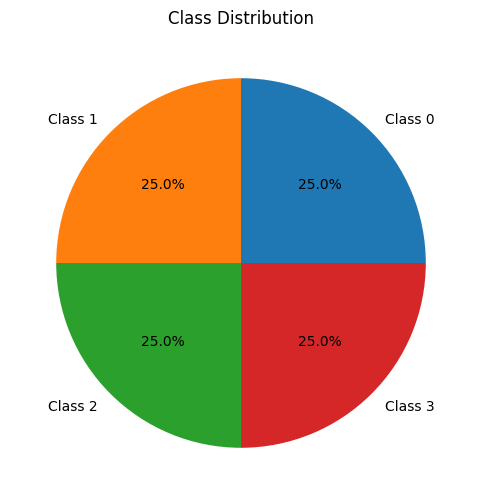


Class Distribution Summary:
----------------------------------------
Class 0: 4,000 samples (25.0%)
Class 1: 4,000 samples (25.0%)
Class 2: 4,000 samples (25.0%)
Class 3: 4,000 samples (25.0%)

Total: 16,000 samples

Observation: Dataset has perfectly balanced classes (4000 samples each).


In [7]:
# Class Distribution Analysis
_, class_counts = np.unique(y, return_counts=True)

# Pie chart showing class proportions
figure, axis = plt.subplots(figsize=(8, 6))
axis.pie(class_counts, labels=CLASS_NAMES, autopct="%1.1f%%", colors=CLASS_COLORS)
axis.set_title("Class Distribution")
plt.show()

print("\nClass Distribution Summary:")
print("-" * 40)
for class_index, count in enumerate[Any](class_counts):
    percentage = (count / TOTAL_SAMPLES) * 100
    print(f"{CLASS_NAMES[class_index]}: {count:,} samples ({percentage:.1f}%)")
print(f"\nTotal: {TOTAL_SAMPLES:,} samples")
print("\nObservation: Dataset has perfectly balanced classes (4000 samples each).")

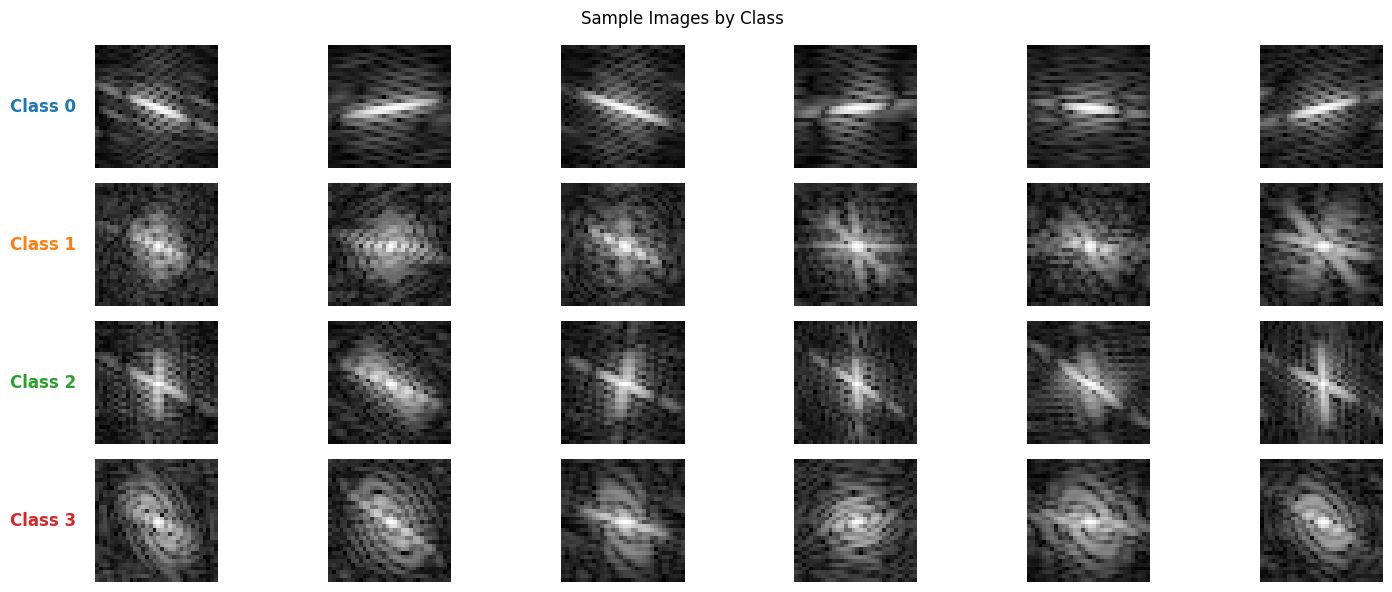


Visual Observations:
Images are 32x32 pixels in grayscale
Each class appears to have certain visual patterns


In [8]:
# Sample Images Visualization - Organized by Class
figure, axes = plt.subplots(
    NUM_CLASSES, SAMPLES_PER_CLASS_VISUALIZATION, figsize=(16, 6)
)
figure.suptitle("Sample Images by Class")

for class_index in range(NUM_CLASSES):
    class_indices = np.where(y == class_index)[0]
    selected_indices = np.random.choice(
        class_indices, size=SAMPLES_PER_CLASS_VISUALIZATION, replace=False
    )

    for sample_position, image_index in enumerate(selected_indices):
        axis = axes[class_index, sample_position]
        axis.imshow(X[image_index], cmap="gray")
        axis.axis("off")

    # Add class label on the left side of each row (with class color)
    axes[class_index, 0].text(
        -0.15,
        0.5,
        CLASS_NAMES[class_index],
        transform=axes[class_index, 0].transAxes,
        fontsize=12,
        fontweight="bold",
        color=CLASS_COLORS[class_index],
        va="center",
        ha="right",
    )

plt.tight_layout()
plt.subplots_adjust(left=0.08)
plt.show()

print("\nVisual Observations:")
print("Images are 32x32 pixels in grayscale")
print("Each class appears to have certain visual patterns")

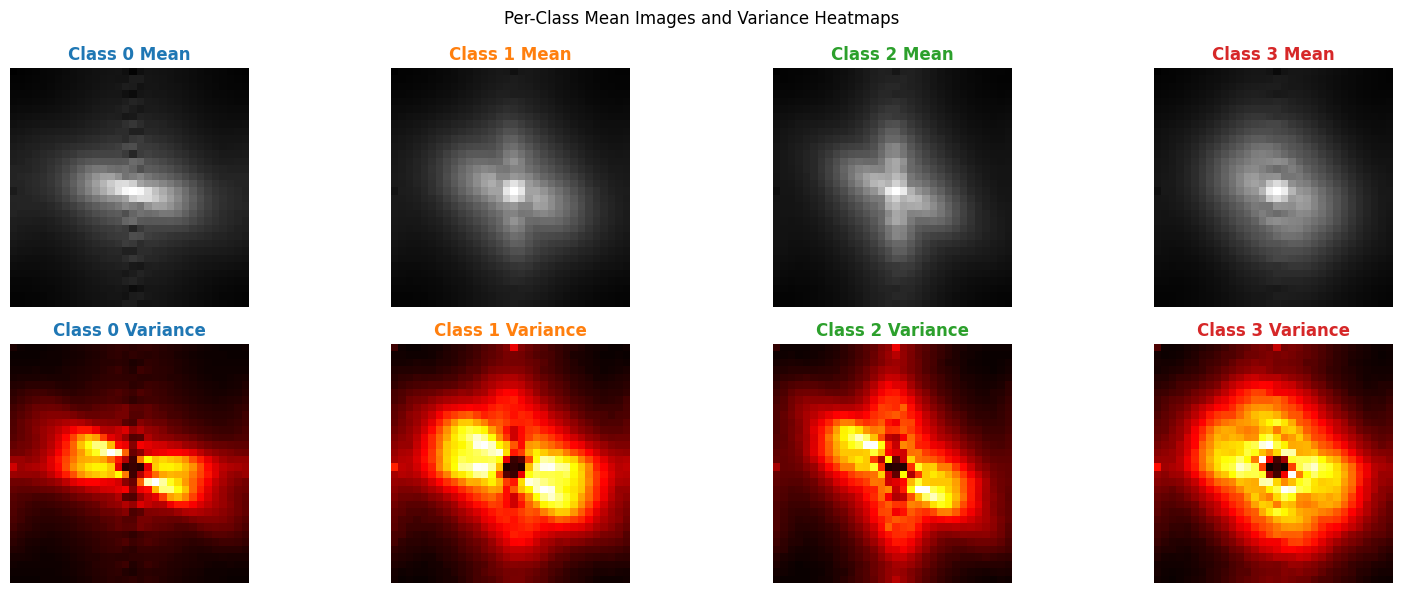


Per-Class Pixel Statistics:
Class    Mean         Std Dev      Max Variance Location
-------------------------------------------------------
0        0.8715       0.6385       (14, 13)
1        1.0933       0.7085       (13, 12)
2        1.0591       0.7129       (13, 13)
3        1.1292       0.7133       (13, 15)


In [9]:
# Per-Class Analysis: Mean Images and Variance Heatmaps
figure, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 6))
figure.suptitle("Per-Class Mean Images and Variance Heatmaps")

class_pixel_statistics = {}

for class_index in range(NUM_CLASSES):
    class_mask = y == class_index
    class_images = X[class_mask]

    mean_image = np.mean(class_images, axis=0)
    variance_image = np.var(class_images, axis=0)

    class_pixel_statistics[class_index] = {
        "mean": np.mean(class_images),
        "std": np.std(class_images),
        "max_variance_location": np.unravel_index(
            np.argmax(variance_image), variance_image.shape
        ),
    }

    # Mean image (with class-colored title)
    axes[0, class_index].imshow(mean_image, cmap="gray")
    axes[0, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Mean",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[0, class_index].axis("off")

    # Variance heatmap (with class-colored title)
    axes[1, class_index].imshow(variance_image, cmap="hot")
    axes[1, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Variance",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[1, class_index].axis("off")

plt.tight_layout()
plt.show()

# Print per-class statistics
print("\nPer-Class Pixel Statistics:")
print(f"{'Class':<8} {'Mean':<12} {'Std Dev':<12} {'Max Variance Location':<20}")
print("-" * 55)
for class_index, statistics in class_pixel_statistics.items():
    location = statistics["max_variance_location"]
    print(
        f"{class_index:<8} {statistics['mean']:<12.4f} {statistics['std']:<12.4f} ({location[0]}, {location[1]})"
    )

## Dataset Inspection

The dataset inspection shows a clean, well-structured image classification corpus of 16,000 grayscale images with shape (16000, 32, 32) stored as float32 (~62.5 MB) and a labels array of length 16,000 with four classes (0,1,2,3). Class counts are perfectly balanced with 4000 samples per class with the proportion of 25%, as visualized by the pie chart, so no class-reweighting is required for training. Sample image mosaics reveal distinct, class specific texture and frequency patterns at 32×32 resolution, suggesting meaningful visual differences that a CNN can exploit after appropriate preprocessing. Per-class mean images highlight characteristic average structures for each class, while the variance heatmaps show that pixel variability is concentrated in central regions with slightly different hotspots per class, consistent with the reported per-class pixel statistics: Class 0 mean 0.8715 (std 0.6385, max-variance at (14,13)); Class 1 mean 1.0933 (std 0.7085, max-variance at (13,12)); Class 2 mean 1.0591 (std 0.7129, max-variance at (13,13)); Class 3 mean 1.1292 (std 0.7133, max-variance at (13,15)). Taken together, these findings confirm a balanced dataset with visually separable classes, but they also indicate the need for consistent normalization (computed from training data only) and adding a channel dimension (32×32→32×32×1) before feeding images to a CNN.

## Data train, validation, test split and preprocessing

To ensure a fair and no leakage evaluation of deep learning models via Convolutional Neural Network, the dataset is firstly divided into training (70%), validation (15%), and test (15%) splits before any preprocessing is applied. The preprocessing steps which include min–max normalization, are computed exclusively on the training set to prevent information from the validation and test sets from influencing the learning process. The derived normalization parameters are applied across all splits, and each image is expanded with a channel dimension (from 32×32 to 32×32×1) to match the expected CNN input format

In [10]:
# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# STEP 1: Split data BEFORE preprocessing

# First split: separate test set (15% of total data)
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)

# Second split: separate train and validation from remaining data
# 15% of original = ~17.6% of remaining (0.15 / 0.85 ≈ 0.176)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp
)

print("Data Split Summary:")
print(
    f"Training set: {X_train_raw.shape[0]:,} samples ({X_train_raw.shape[0]/len(y)*100:.1f}%)"
)
print(
    f"Validation set: {X_val_raw.shape[0]:,} samples ({X_val_raw.shape[0]/len(y)*100:.1f}%)"
)
print(
    f"Test set: {X_test_raw.shape[0]:,} samples ({X_test_raw.shape[0]/len(y)*100:.1f}%)"
)

# Verify stratification
print("\nClass Distribution in Splits:")
print(f"{'Class':<8} {'Train':<12} {'Validation':<12} {'Test':<12}")
print("-" * 45)
for class_index in range(NUM_CLASSES):
    train_count = np.sum(y_train == class_index)
    val_count = np.sum(y_val == class_index)
    test_count = np.sum(y_test == class_index)
    print(f"{class_index:<8} {train_count:<12} {val_count:<12} {test_count:<12}")


# STEP 2: Compute normalization statistics from TRAINING DATA ONLY
PIXEL_MIN = X_train_raw.min()
PIXEL_MAX = X_train_raw.max()

print(f"Raw min value before normalization: {PIXEL_MIN:.4f}")
print(f"Raw max value before normalization: {PIXEL_MAX:.4f}")


# STEP 3: Define preprocessing function using TRAINING statistics
def preprocess_data(X_raw, pixel_min=PIXEL_MIN, pixel_max=PIXEL_MAX):
    # Normalize using provided statistics (default: training statistics)
    X_normalized = (X_raw - pixel_min) / (pixel_max - pixel_min)

    # Clip values to [0, 1] in case test data has values outside training range
    X_normalized = np.clip(X_normalized, 0, 1)

    # Add channel dimension for CNN
    X_processed = X_normalized[..., np.newaxis]

    return X_processed.astype(np.float32)


# STEP 4: Apply preprocessing to all splits using TRAINING statistics
X_train = preprocess_data(X_train_raw)
X_val = preprocess_data(X_val_raw)
X_test = preprocess_data(X_test_raw)

print("\nPreprocessing Applied (using training statistics):")
print(f"X_train: {X_train.shape}, range [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"X_val:   {X_val.shape}, range [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"X_test:  {X_test.shape}, range [{X_test.min():.4f}, {X_test.max():.4f}]")

Data Split Summary:
Training set: 11,206 samples (70.0%)
Validation set: 2,394 samples (15.0%)
Test set: 2,400 samples (15.0%)

Class Distribution in Splits:
Class    Train        Validation   Test        
---------------------------------------------
0        2801         599          600         
1        2802         598          600         
2        2801         599          600         
3        2802         598          600         
Raw min value before normalization: 0.0000
Raw max value before normalization: 5.0696

Preprocessing Applied (using training statistics):
X_train: (11206, 32, 32, 1), range [0.0000, 1.0000]
X_val:   (2394, 32, 32, 1), range [0.0000, 0.9922]
X_test:  (2400, 32, 32, 1), range [0.0000, 0.9910]


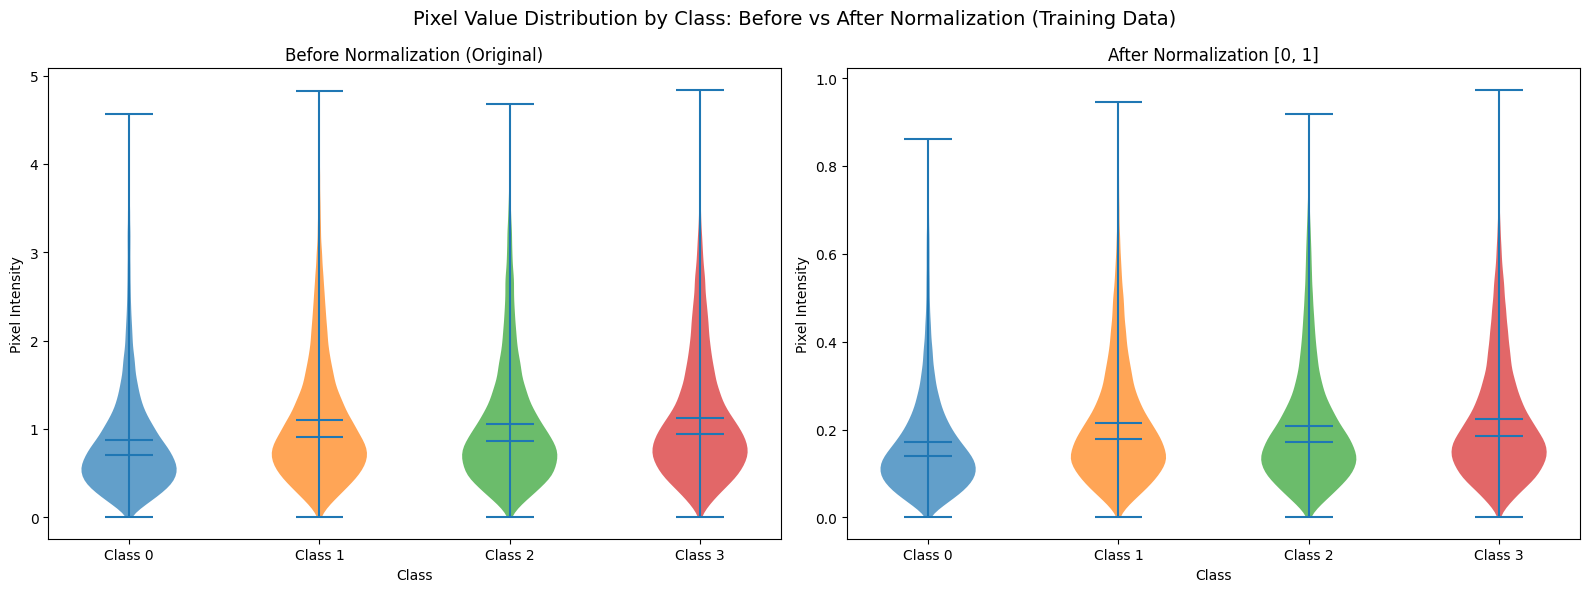


Pixel Value Statistics Comparison - TRAINING DATA (Original vs Normalized):
-------------------------------------------------------------------------------------------------------------------
Class      ori_mean   norm_mean   ori_std    norm_std   ori_min    norm_min   ori_max    norm_max  
-------------------------------------------------------------------------------------------------------------------
Class 0    0.8715     0.1719      0.6382     0.1259     0.0001     0.0000     4.6706     0.9213    
Class 1    1.0928     0.2156      0.7086     0.1398     0.0000     0.0000     5.0577     0.9977    
Class 2    1.0587     0.2088      0.7131     0.1407     0.0001     0.0000     5.0373     0.9936    
Class 3    1.1295     0.2228      0.7131     0.1407     0.0003     0.0001     5.0696     1.0000    


In [11]:
# Helper functions for pixel distribution visualization
def sample_pixels_by_class(data, labels, sample_size):
    sampled_pixels = []
    for class_index in range(NUM_CLASSES):
        class_pixels = data[labels == class_index].flatten()
        if len(class_pixels) > sample_size:
            sampled = np.random.choice(class_pixels, size=sample_size, replace=False)
        else:
            sampled = class_pixels
        sampled_pixels.append(sampled)
    return sampled_pixels


def configure_violin_plot(axis, violin_parts, title):
    for class_index, body in enumerate(violin_parts["bodies"]):
        body.set_facecolor(CLASS_COLORS[class_index])
        body.set_alpha(0.7)
    axis.set_ylabel("Pixel Intensity")
    axis.set_xlabel("Class")
    axis.set_title(title)
    axis.set_xticks(range(1, NUM_CLASSES + 1))
    axis.set_xticklabels(CLASS_NAMES)


# Compare pixel value distributions: Before vs After Normalization (TRAINING DATA ONLY)
figure, axes = plt.subplots(1, 2, figsize=(16, 6))
figure.suptitle(
    "Pixel Value Distribution by Class: Before vs After Normalization (Training Data)",
    fontsize=14,
)

# Prepare sampled data for both plots (using TRAINING data only)
pixels_before_norm = sample_pixels_by_class(X_train_raw, y_train, PIXEL_SAMPLE_SIZE)
pixels_after_norm = sample_pixels_by_class(X_train, y_train, PIXEL_SAMPLE_SIZE)

# Create and configure violin plots
plot_configs = [
    (axes[0], pixels_before_norm, "Before Normalization (Original)"),
    (axes[1], pixels_after_norm, "After Normalization [0, 1]"),
]

for axis, pixel_data, title in plot_configs:
    violin_parts = axis.violinplot(pixel_data, showmeans=True, showmedians=True)
    configure_violin_plot(axis, violin_parts, title)

plt.tight_layout()
plt.show()

# Print comparison statistics (TRAINING DATA ONLY)
print("\nPixel Value Statistics Comparison - TRAINING DATA (Original vs Normalized):")
print("-" * 115)
print(
    f"{'Class':<10} {'ori_mean':<10} {'norm_mean':<11} {'ori_std':<10} {'norm_std':<10} "
    f"{'ori_min':<10} {'norm_min':<10} {'ori_max':<10} {'norm_max':<10}"
)
print("-" * 115)
for class_index in range(NUM_CLASSES):
    class_mask = y_train == class_index
    ori_data = X_train_raw[class_mask]
    norm_data = X_train[class_mask]
    print(
        f"{CLASS_NAMES[class_index]:<10} "
        f"{ori_data.mean():<10.4f} {norm_data.mean():<11.4f} "
        f"{ori_data.std():<10.4f} {norm_data.std():<10.4f} "
        f"{ori_data.min():<10.4f} {norm_data.min():<10.4f} "
        f"{ori_data.max():<10.4f} {norm_data.max():<10.4f}"
    )

After normalization, all four classes retain the same overall distribution shapes as their original pixel intensities. The normalization simply rescales values into the $[0,1]$ range without altering the underlying class-specific patterns, meaning the relative brightness characteristics of each class remain unchanged. The transformation applied to each pixel value $x$ follows the standard min–max scaling formula:

$$
x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

where $x_{\min}$ and $x_{\max}$ represent the minimum and maximum pixel intensities computed from the **training set only**.


## 4. Architecture Reasoning

### Why Convolutional Neural Network (CNN)?

CNNs are the ideal choice for this image classification task because:

1. **Spatial Hierarchy Learning**: CNNs can learn hierarchical features - from simple edges in early layers to complex patterns in deeper layers
2. **Translation Invariance**: Convolutional layers with pooling provide robustness to small shifts in the image
3. **Parameter Efficiency**: Weight sharing in convolutional kernels significantly reduces parameters compared to fully-connected networks
4. **Proven Performance**: CNNs are the state-of-the-art for image classification tasks

### Architecture Design

Given the input size (32×32×1), we design a compact yet effective CNN:

| Layer | Output Shape | Parameters | Rationale |
|-------|-------------|------------|-----------|
| Input | 32×32×1 | - | Grayscale image |
| Conv2D (32 filters, 3×3) | 30×30×32 | 320 | Extract low-level features (edges, textures) |
| BatchNorm + ReLU | 30×30×32 | 64 | Stabilize training, add non-linearity |
| MaxPool2D (2×2) | 15×15×32 | - | Reduce spatial dimensions, add translation invariance |
| Conv2D (64 filters, 3×3) | 13×13×64 | 18,496 | Extract mid-level features (shapes, parts) |
| BatchNorm + ReLU | 13×13×64 | 128 | Stabilize training |
| MaxPool2D (2×2) | 6×6×64 | - | Further spatial reduction |
| Conv2D (128 filters, 3×3) | 4×4×128 | 73,856 | Extract high-level features (patterns) |
| BatchNorm + ReLU | 4×4×128 | 256 | Stabilize training |
| GlobalAvgPool2D | 128 | - | Reduce to feature vector, less overfitting than Flatten |
| Dropout (0.5) | 128 | - | Regularization |
| Dense (64) | 64 | 8,256 | Learn class-specific combinations |
| Dense (4, softmax) | 4 | 260 | 4-class output probabilities |

### Design Decisions

- **Filter progression (32→64→128)**: Gradually increasing filters captures increasingly complex features
- **3×3 kernels**: Small kernels are computationally efficient and when stacked, can capture large receptive fields
- **BatchNormalization**: Accelerates training and provides mild regularization
- **GlobalAveragePooling**: Reduces overfitting compared to Flatten+Dense; creates more interpretable feature maps
- **Dropout (50%)**: Strong regularization to prevent overfitting on ~11,200 training samples


## 4. Model Implementation

### Building the CNN Architecture


In [12]:
def get_augmentation_layer(augmentation_type):
    """
    Create augmentation layer based on type.

    Parameters:
        augmentation_type: str or None
            - None: No augmentation
            - "geometric": Rotation, zoom, translation (destroys spatial features)
            - "noise": Gaussian noise and contrast (preserves spatial features)

    Returns:
        Keras Sequential layer or None
    """
    if augmentation_type is None:
        return None
    elif augmentation_type == "geometric":
        return keras.Sequential([
            layers.RandomRotation(0.1),         # ±36° rotation
            layers.RandomZoom(0.1),             # ±10% zoom
            layers.RandomTranslation(0.1, 0.1)  # ±10% shift
        ], name='geometric_augmentation')
    elif augmentation_type == "noise":
        return keras.Sequential([
            layers.GaussianNoise(0.05),         # Add slight noise
        ], name='noise_augmentation')
    else:
        raise ValueError(f"Unknown augmentation type: {augmentation_type}")


def build_cnn_model(input_shape, num_classes, augmentation_type=None,
                    learning_rate=0.001, label_smoothing=0.0):
    """
    Build a CNN model for image classification with configurable options.

    Parameters:
        input_shape: tuple, shape of input images (height, width, channels)
        num_classes: int, number of output classes
        augmentation_type: str or None - "geometric", "noise", or None
        learning_rate: float, learning rate for Adam optimizer
        label_smoothing: float, label smoothing factor (0.0 = no smoothing)

    Returns:
        model: compiled Keras model
        use_onehot: bool, whether the model requires one-hot encoded labels
    """
    inputs = layers.Input(shape=input_shape)

    # Apply data augmentation if specified
    augmentation_layer = get_augmentation_layer(augmentation_type)
    if augmentation_layer is not None:
        x = augmentation_layer(inputs)
    else:
        x = inputs

    # First Convolutional Block
    x = layers.Conv2D(32, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Second Convolutional Block
    x = layers.Conv2D(64, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Third Convolutional Block
    x = layers.Conv2D(128, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layers
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Choose loss function based on label smoothing
    # Label smoothing requires CategoricalCrossentropy with one-hot labels
    if label_smoothing > 0:
        loss = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
        use_onehot = True
    else:
        loss = 'sparse_categorical_crossentropy'
        use_onehot = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['accuracy']
    )

    return model, use_onehot


# Define input shape
INPUT_SHAPE = X_train.shape[1:]  # (32, 32, 1)

# Prepare one-hot encoded labels for label smoothing experiments
y_train_onehot = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_onehot = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_onehot = keras.utils.to_categorical(y_test, NUM_CLASSES)

print("Model Builder Configuration:")
print(f"  Input shape: {INPUT_SHAPE}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  One-hot labels prepared: y_train_onehot {y_train_onehot.shape}")

Model Builder Configuration:
  Input shape: (32, 32, 1)
  Number of classes: 4
  One-hot labels prepared: y_train_onehot (11206, 4)


---

## Ablation Study: Run All Model Combinations

This section runs experiments with all combinations of:
- **Augmentation**: None, Geometric (rotation/zoom/translation), Noise (Gaussian)
- **Label Smoothing**: 0.0 (none), 0.1 (10%)

This creates a comprehensive comparison of different regularization techniques.


In [13]:
# EXPERIMENT CONFIGURATION
# Define all experiment configurations
EXPERIMENT_CONFIGS = [
    # (name, augmentation_type, label_smoothing)
    ("Baseline", None, 0.1),
    ("Geometric Aug", "geometric", 0.1),
    ("Label smoothing", None, 0.1),
    ("Geometric + Label smoothing", "geometric", 0.1),
]

# Training configuration
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

def run_experiment(name, augmentation_type, label_smoothing, verbose=0):
    """
    Run a single experiment with specified configuration.

    Returns:
        dict with model, history, and metrics
    """
    print(f"EXPERIMENT: {name} - {augmentation_type or 'None'} - {label_smoothing}")

    # Reset random seeds for fair comparison
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    # Build model
    model, use_onehot = build_cnn_model(
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        augmentation_type=augmentation_type,
        learning_rate=LEARNING_RATE,
        label_smoothing=label_smoothing
    )

    # Select appropriate labels
    train_labels = y_train_onehot if use_onehot else y_train
    val_labels = y_val_onehot if use_onehot else y_val

    # Define callbacks
    exp_callbacks = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
        ),
    ]

    # Train
    history = model.fit(
        X_train, train_labels,
        validation_data=(X_val, val_labels),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=exp_callbacks,
        verbose=verbose
    )

    # Get final metrics
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    final_train_acc = history.history['accuracy'][-1]
    epochs_trained = len(history.history['loss'])

    print(f"Accuracy [{best_val_acc:.4f} ({best_val_acc*100:.2f}%)] - Loss [{best_val_loss:.4f}] - Epochs: [{epochs_trained}]")

    return {
        'name': name,
        'augmentation': augmentation_type,
        'label_smoothing': label_smoothing,
        'model': model,
        'history': history,
        'use_onehot': use_onehot,
        'best_val_acc': best_val_acc,
        'best_val_loss': best_val_loss,
        'final_train_acc': final_train_acc,
        'epochs_trained': epochs_trained
    }

print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"\nExperiments to run: {len(EXPERIMENT_CONFIGS)}")
for name, aug, ls in EXPERIMENT_CONFIGS:
    print(f"  - {name}: aug={aug or 'None'}, label_smoothing={ls}")

Epochs: 50
Batch Size: 32
Learning Rate: 0.001

Experiments to run: 4
  - Baseline: aug=None, label_smoothing=0.1
  - Geometric Aug: aug=geometric, label_smoothing=0.1
  - Label smoothing: aug=None, label_smoothing=0.1
  - Geometric + Label smoothing: aug=geometric, label_smoothing=0.1


In [14]:
# RUN ALL EXPERIMENTS
# Store all results
all_results = []

for i, (name, aug_type, label_smooth) in enumerate(EXPERIMENT_CONFIGS):
    print(f"\n[{i+1}/{len(EXPERIMENT_CONFIGS)}] Running: {name}")
    result = run_experiment(name, aug_type, label_smooth, verbose=0)
    all_results.append(result)


[1/4] Running: Baseline
EXPERIMENT: Baseline - None - 0.1

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
Accuracy [0.9444 (94.44%)] - Loss [0.4717] - Epochs: [16]

[2/4] Running: Geometric Aug
EXPERIMENT: Geometric Aug - geometric - 0.1

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 19.
Accuracy [0.9177 (91.77%)] - Loss [0.5222] - Epochs: [29]

[3/4] Running: Label smoothing
EXPERIMENT: Label smoothing - None - 0.1

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing lear

In [15]:
# RESULTS SUMMARY TABLE
print("\n" + "="*90)
print("EXPERIMENT RESULTS SUMMARY")
print("="*90)
print(f"\n{'Model':<20} {'Val Acc':<12} {'Val Loss':<12} {'Train Acc':<12} {'Epochs':<10} {'Aug':<12} {'LS':<8}")
print("-"*90)

# Sort by validation accuracy (descending)
sorted_results = sorted(all_results, key=lambda x: x['best_val_acc'], reverse=True)

for r in sorted_results:
    aug_str = r['augmentation'] or 'None'
    ls_str = f"{r['label_smoothing']:.1f}"
    print(f"{r['name']:<20} {r['best_val_acc']:.4f}       {r['best_val_loss']:.4f}       "
          f"{r['final_train_acc']:.4f}       {r['epochs_trained']:<10} {aug_str:<12} {ls_str:<8}")

# Find best model
best_result = sorted_results[0]
print("\n" + "-"*90)
print(f"BEST MODEL: {best_result['name']} with {best_result['best_val_acc']*100:.2f}% validation accuracy")
print("-"*90)

# Calculate relative performance
baseline_acc = next(r['best_val_acc'] for r in all_results if r['name'] == 'Baseline')
print(f"\nPerformance relative to Baseline ({baseline_acc*100:.2f}%):")
for r in sorted_results:
    diff = (r['best_val_acc'] - baseline_acc) * 100
    sign = "+" if diff >= 0 else ""
    print(f"  {r['name']:<20}: {sign}{diff:.2f}%")


EXPERIMENT RESULTS SUMMARY

Model                Val Acc      Val Loss     Train Acc    Epochs     Aug          LS      
------------------------------------------------------------------------------------------
Label smoothing      0.9674       0.4479       0.9977       14         None         0.1     
Baseline             0.9444       0.4717       0.9986       16         None         0.1     
Geometric Aug        0.9177       0.5222       0.9566       29         geometric    0.1     
Geometric + Label smoothing 0.9077       0.5241       0.9544       36         geometric    0.1     

------------------------------------------------------------------------------------------
BEST MODEL: Label smoothing with 96.74% validation accuracy
------------------------------------------------------------------------------------------

Performance relative to Baseline (94.44%):
  Label smoothing     : +2.30%
  Baseline            : +0.00%
  Geometric Aug       : -2.67%
  Geometric + Label smoothin

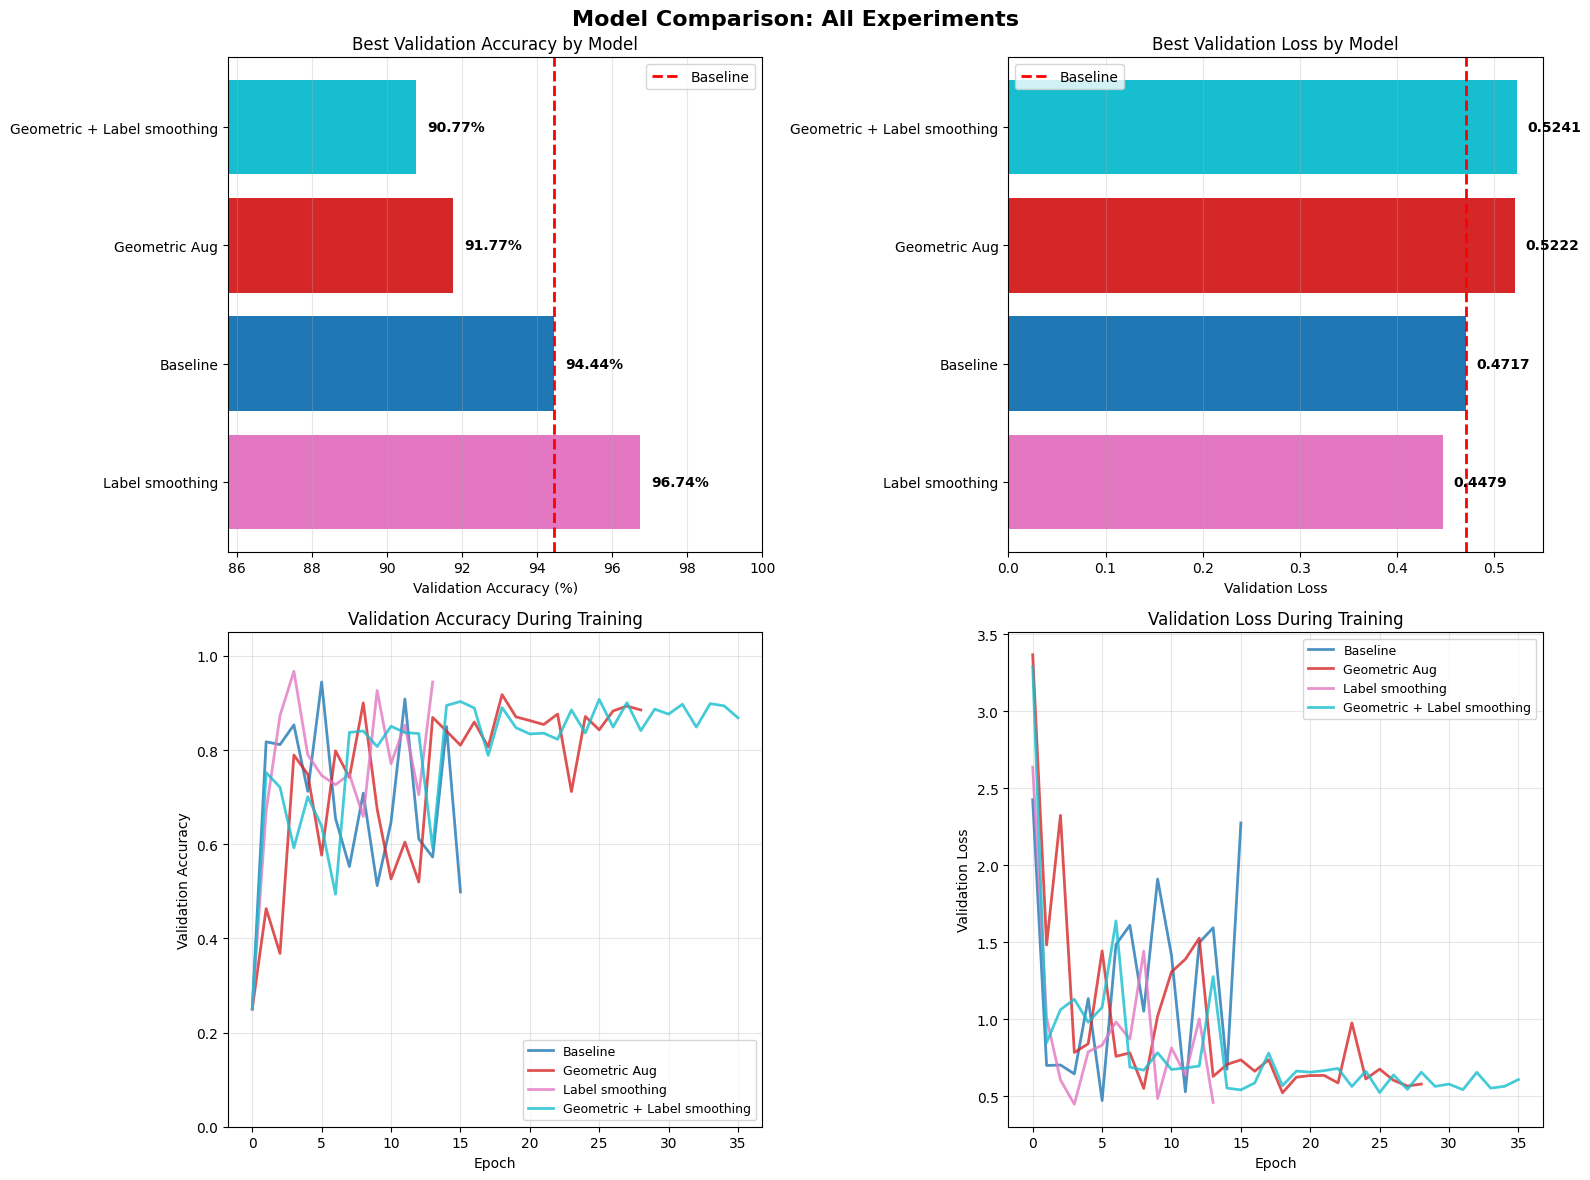

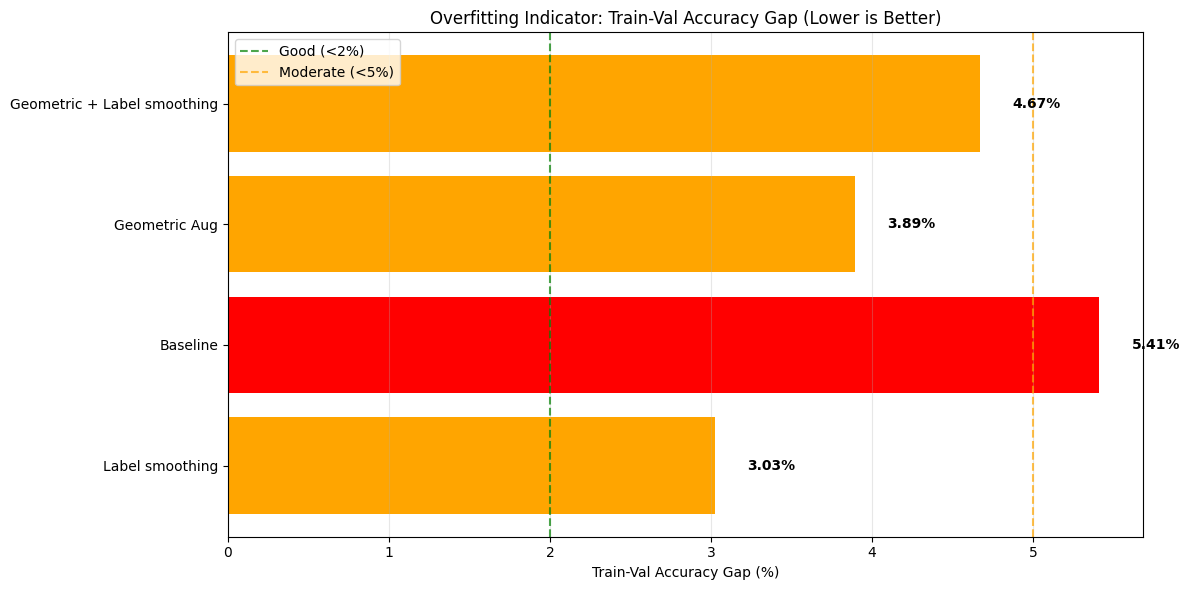

In [ ]:
# COMPARISON CHARTS

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Model Comparison: All Experiments", fontsize=16, fontweight='bold')

# Color palette for models
base_colors = COLOR_PALETTE
colors = [base_colors[i % len(base_colors)] for i in range(len(all_results))]

# --- Chart 1: Validation Accuracy Bar Chart ---
ax1 = axes[0, 0]
names = [r['name'] for r in sorted_results]
val_accs = [r['best_val_acc'] * 100 for r in sorted_results]
bars = ax1.barh(names, val_accs, color=[colors[all_results.index(r)] for r in sorted_results])
ax1.set_xlabel('Validation Accuracy (%)')
ax1.set_title('Best Validation Accuracy by Model')
ax1.set_xlim(min(val_accs) - 5, 100)
ax1.axvline(x=baseline_acc * 100, color='red', linestyle='--', linewidth=2, label='Baseline')
for i, (bar, acc) in enumerate(zip(bars, val_accs)):
    ax1.text(acc + 0.3, bar.get_y() + bar.get_height()/2, f'{acc:.2f}%',
             va='center', fontsize=10, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# --- Chart 2: Validation Loss Bar Chart ---
ax2 = axes[0, 1]
val_losses = [r['best_val_loss'] for r in sorted_results]
bars2 = ax2.barh(names, val_losses, color=[colors[all_results.index(r)] for r in sorted_results])
ax2.set_xlabel('Validation Loss')
ax2.set_title('Best Validation Loss by Model')
baseline_loss = next(r['best_val_loss'] for r in all_results if r['name'] == 'Baseline')
ax2.axvline(x=baseline_loss, color='red', linestyle='--', linewidth=2, label='Baseline')
for bar, loss in zip(bars2, val_losses):
    ax2.text(loss + 0.01, bar.get_y() + bar.get_height()/2, f'{loss:.4f}',
             va='center', fontsize=10, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

# --- Chart 3: Training Curves - Validation Accuracy ---
ax3 = axes[1, 0]
for i, r in enumerate(all_results):
    ax3.plot(r['history'].history['val_accuracy'], label=r['name'],
             color=colors[i], linewidth=2, alpha=0.8)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Validation Accuracy')
ax3.set_title('Validation Accuracy During Training')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.05)

# --- Chart 4: Training Curves - Validation Loss ---
ax4 = axes[1, 1]
for i, r in enumerate(all_results):
    ax4.plot(r['history'].history['val_loss'], label=r['name'],
             color=colors[i], linewidth=2, alpha=0.8)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Loss')
ax4.set_title('Validation Loss During Training')
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Additional: Train vs Val Accuracy Gap Chart ---
fig2, ax5 = plt.subplots(figsize=(12, 6))
gaps = [r['final_train_acc'] - r['best_val_acc'] for r in sorted_results]
colors_gap = ['green' if g < 0.02 else 'orange' if g < 0.05 else 'red' for g in gaps]
bars3 = ax5.barh(names, [g * 100 for g in gaps], color=colors_gap)
ax5.set_xlabel('Train-Val Accuracy Gap (%)')
ax5.set_title('Overfitting Indicator: Train-Val Accuracy Gap (Lower is Better)')
ax5.axvline(x=2, color='green', linestyle='--', alpha=0.7, label='Good (<2%)')
ax5.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Moderate (<5%)')
for bar, gap in zip(bars3, gaps):
    ax5.text(gap * 100 + 0.2, bar.get_y() + bar.get_height()/2, f'{gap*100:.2f}%',
             va='center', fontsize=10, fontweight='bold')
ax5.legend()
ax5.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# SAVE BEST MODEL

# Use the best performing model (by validation accuracy)
model = best_result['model']
history = best_result['history']

# Save the best model
MODEL_PATH = "model_s3343711.h5"
model.save(MODEL_PATH)

print(f"Best model saved: {MODEL_PATH}")
print(f"  Model: {best_result['name']}")
print(f"  Validation Accuracy: {best_result['best_val_acc']*100:.2f}%")
print(f"  File size: {os.path.getsize(MODEL_PATH) / (1024 * 1024):.2f} MB")


Best model saved: model_s3343711.h5
  Model: Label smoothing
  Validation Accuracy: 96.74%
  File size: 1.24 MB


---

## Option A: Load Trained Model

This section loads a pre-trained model from the saved `.h5` file. Use this option for quick evaluation without retraining.


In [18]:
# Load the pre-trained model
MODEL_PATH = "model_s3343711.h5"
model = keras.models.load_model(MODEL_PATH)

print(f"Model loaded from: {MODEL_PATH}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

# Quick summary
model.summary()

Model loaded from: model_s3343711.h5
Model input shape: (None, 32, 32, 1)
Model output shape: (None, 4)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,086 (398.78 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

---

## Prediction Function

The `predict_fn` function is the standardized interface for model predictions. It works after either Option A or Option B.


In [19]:
def predict_fn(X32x32: np.ndarray) -> np.ndarray:
    """
    Prediction function using the trained model.

    Uses PIXEL_MIN and PIXEL_MAX from TRAINING DATA for normalization
    to ensure consistency and avoid data leakage.

    Parameters:
        X32x32: Input images of shape (N, 32, 32) or (32, 32)

    Returns:
        Predicted class labels as np.int64 array
    """
    # Ensure input is the correct shape
    if X32x32.ndim == 2:
        # Single image: (32, 32) -> (1, 32, 32)
        X32x32 = X32x32[np.newaxis, ...]

    # Preprocess using TRAINING data statistics (stored globally)
    # This ensures consistent preprocessing and no data leakage
    X_normalized = (X32x32 - PIXEL_MIN) / (PIXEL_MAX - PIXEL_MIN)

    # Clip values to [0, 1] in case input has values outside training range
    X_normalized = np.clip(X_normalized, 0, 1)

    # Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
    X_preprocessed = X_normalized[..., np.newaxis].astype(np.float32)

    # Get model predictions (probabilities)
    predictions_proba = model.predict(X_preprocessed, verbose=0)

    # Convert probabilities to class labels
    predictions = np.argmax(predictions_proba, axis=1).astype(np.int64)

    return predictions

# Test the predict_fn with samples from the TEST set (untouched data)
print("Testing predict_fn with TEST SET samples...")
print(f"Using normalization statistics from training data:")
print(f"PIXEL_MIN: {PIXEL_MIN:.4f}")
print(f"PIXEL_MAX: {PIXEL_MAX:.4f}")
print()

# Use raw test data to verify predict_fn works correctly
test_samples = X_test_raw[:5]
test_predictions = predict_fn(test_samples)
print(f"Input shape: {test_samples.shape}")
print(f"Output shape: {test_predictions.shape}")
print(f"Output dtype: {test_predictions.dtype}")
print(f"Predicted labels: {test_predictions}")
print(f"True labels: {y_test[:5]}")


Testing predict_fn with TEST SET samples...
Using normalization statistics from training data:
PIXEL_MIN: 0.0000
PIXEL_MAX: 5.0696

Input shape: (5, 32, 32)
Output shape: (5,)
Output dtype: int64
Predicted labels: [2 1 2 3 0]
True labels: [2 1 2 3 0]
